In [4]:
import os
import shutil
import random
from tqdm import tqdm  # 进度条工具，pip install tqdm

# --- 配置路径 ---
raw_data_path = r'G:\ML\Garbage_Project\data\raw\garbage_classify\train_data'
processed_base_path = r'G:\ML\Garbage_Project\data\processed'
split_ratio = 0.8  # 80% 用于训练, 20% 用于验证

def organize_data():
    # 1. 获取所有图片和txt的配对信息
    # 我们以txt文件为基准进行扫描
    all_files = os.listdir(raw_data_path)
    txt_files = [f for f in all_files if f.endswith('.txt')]
    
    print(f"检测到 {len(txt_files)} 条数据记录。开始分类...")

    # 随机打乱数据，用于切分训练集和验证集
    random.shuffle(txt_files)
    split_idx = int(len(txt_files) * split_ratio)
    
    train_txts = txt_files[:split_idx]
    val_txts = txt_files[split_idx:]

    def process_set(file_list, set_name):
        for txt_name in tqdm(file_list, desc=f"正在处理 {set_name}"):
            txt_path = os.path.join(raw_data_path, txt_name)
            
            # 读取txt内容，获取类别标签
            with open(txt_path, 'r', encoding='utf-8') as f:
                content = f.read().strip() # 内容如: img_1.jpg, 0
                if ',' not in content: continue
                
                img_name, label = content.split(',')
                img_name = img_name.strip()
                label = label.strip()

                # 构建目标文件夹：processed/train/0/ 或 processed/val/0/
                target_folder = os.path.join(processed_base_path, set_name, label)
                os.makedirs(target_folder, exist_ok=True)

                # 复制图片到目标文件夹
                src_img_path = os.path.join(raw_data_path, img_name)
                if os.path.exists(src_img_path):
                    shutil.copy(src_img_path, os.path.join(target_folder, img_name))

    # 执行处理
    process_set(train_txts, 'train')
    process_set(val_txts, 'val')
    print("\n✅ 数据整理完成！")
    print(f"训练集存放在: {os.path.join(processed_base_path, 'train')}")
    print(f"验证集存放在: {os.path.join(processed_base_path, 'val')}")

if __name__ == "__main__":
    organize_data()

检测到 14802 条数据记录。开始分类...


正在处理 val: 100%|██████████| 2961/2961 [00:08<00:00, 329.83it/s]


✅ 数据整理完成！
训练集存放在: G:\ML\Garbage_Project\data\processed\train
验证集存放在: G:\ML\Garbage_Project\data\processed\val


In [2]:
!pip install tqdm ipykernel

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [1]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"当前显卡: {torch.cuda.get_device_name(0)}")
else:
    print("❌ 警告：目前使用的是 CPU，这会让训练变慢。请检查 CUDA 安装。")

PyTorch 版本: 2.5.1+cu121
CUDA 是否可用: True
当前显卡: NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 定义预处理流程
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # 随机裁剪并缩放
    transforms.RandomHorizontalFlip(), # 随机水平翻转
    transforms.RandomRotation(15),     # 随机旋转正负15度
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证集不需要随机，保持原样即可
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. 加载数据集 (路径改为你整理后的路径)
train_dir = r'G:\ML\Garbage_Project\data\processed\train'
val_dir = r'G:\ML\Garbage_Project\data\processed\val'

train_data = datasets.ImageFolder(root=train_dir, transform=train_transform) # 使用带增强的
val_data = datasets.ImageFolder(root=val_dir, transform=val_transform)       # 使用标准化的

# 3. 创建 DataLoader (吴恩达老师讲的 Mini-batch 就体现在这里)
# 4060 显卡建议 batch_size 设为 32 或 64
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"训练集大小: {len(train_data)} 张图片")
print(f"验证集大小: {len(val_data)} 张图片")
print(f"类别映射: {train_data.class_to_idx}")

训练集大小: 11841 张图片
验证集大小: 2961 张图片
类别映射: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '5': 35, '6': 36, '7': 37, '8': 38, '9': 39}


In [3]:
import torch.nn as nn
from torchvision import models

# 1. 选一个 GPU 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用设备: {device}")

# 2. 加载一个预训练好的 ResNet18 模型 (巨人本人)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 3. 修改最后一层（ResNet 默认输出 1000 类，我们要改成 40 类）
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 40) # 这里的 40 就是你的垃圾类别总数

# 4. 把模型搬到 GPU 上
model = model.to(device)

print("模型构建完成，已发送至 4060 显卡！")

正在使用设备: cuda
模型构建完成，已发送至 4060 显卡！


In [7]:
import torch.optim as optim

# 定义损失函数 (多分类问题的标配)
criterion = nn.CrossEntropyLoss()

# 定义优化器 (学习率设为 0.001 是一个很好的初始值)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [8]:
import time

# 设定训练轮数（2万张图，4060显卡，先跑5轮看看效果）
num_epochs = 10

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # 每个 epoch 包含一个训练阶段和一个验证阶段
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # 训练模式：允许更新梯度
            dataloader = train_loader
        else:
            model.eval()   # 验证模式：关闭梯度更新，只考考它
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        # 遍历数据 (Mini-batch)
        for inputs, labels in dataloader:
            inputs = inputs.to(device) # 把图丢进显卡
            labels = labels.to(device) # 把标准答案丢进显卡

            # 梯度清零（吴恩达老师讲过，每一轮都要重新算斜率）
            optimizer.zero_grad()

            # 前向传播 (Forward)
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1) # 找到概率最大的那个分类
                loss = criterion(outputs, labels)

                # 反向传播 + 优化 (仅在训练阶段执行)
                if phase == 'train':
                    loss.backward()  # 算梯度
                    optimizer.step() # 迈出一小步（梯度下降）

            # 统计误差和准确率
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print('🎉 训练完成！')

Epoch 1/10
----------
train Loss: 1.6805 Acc: 0.5707
val Loss: 1.2394 Acc: 0.7055
Epoch 2/10
----------
train Loss: 1.3075 Acc: 0.6336
val Loss: 1.1213 Acc: 0.7160
Epoch 3/10
----------
train Loss: 1.2214 Acc: 0.6534
val Loss: 0.9970 Acc: 0.7383
Epoch 4/10
----------
train Loss: 1.1248 Acc: 0.6831
val Loss: 1.0043 Acc: 0.7345
Epoch 5/10
----------
train Loss: 1.0505 Acc: 0.6983
val Loss: 0.9495 Acc: 0.7454
Epoch 6/10
----------
train Loss: 1.0108 Acc: 0.7044
val Loss: 0.9650 Acc: 0.7410
Epoch 7/10
----------
train Loss: 0.9573 Acc: 0.7233
val Loss: 0.9338 Acc: 0.7450
Epoch 8/10
----------
train Loss: 0.9390 Acc: 0.7277
val Loss: 0.9330 Acc: 0.7511
Epoch 9/10
----------
train Loss: 0.9056 Acc: 0.7379
val Loss: 0.8636 Acc: 0.7508
Epoch 10/10
----------
train Loss: 0.8542 Acc: 0.7471
val Loss: 0.8634 Acc: 0.7633
🎉 训练完成！


g:\Anaconda\envs\garbage_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
g:\Anaconda\envs\garbage_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
g:\Anaconda\envs\garbage_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
g:\Anaconda\envs\garbage_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


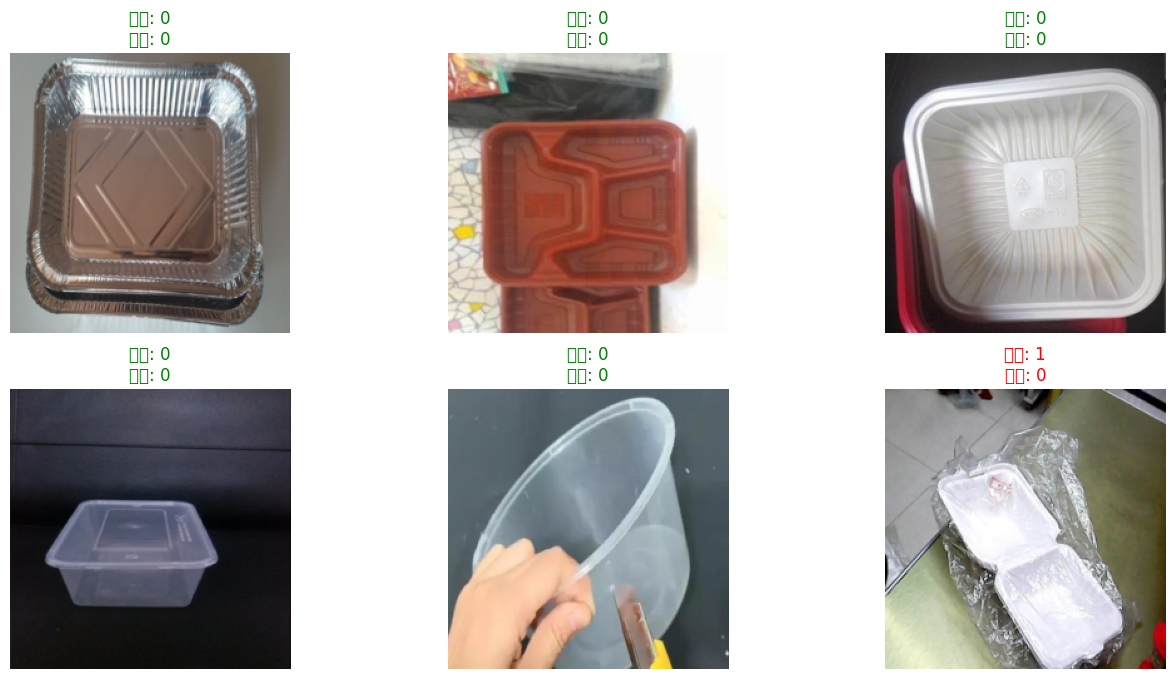

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 切换到验证模式
model.eval()

# 2. 获取一批数据
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

# 3. 进行预测
outputs = model(images)
_, preds = torch.max(outputs, 1)

# 4. 绘图展示
plt.figure(figsize=(16, 8))
# 这里的 40 对应你的字典映射，建议用之前的 class_to_idx 反转一下
class_names = list(train_data.class_to_idx.keys())

for i in range(6):
    plt.subplot(2, 3, i+1)
    # 反归一化图片以便显示
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"预测: {class_names[preds[i]]}\n实际: {class_names[labels[i]]}", color=color)
    plt.axis('off')

plt.show()

In [ ]:
# 保存模型权重
torch.save(model.state_dict(), 'garbage_resnet18_v2.pth')
print("模型已成功保存！这是你人生中第一个准工业级模型。")

模型已成功保存！这是你人生中第一个准工业级模型。


In [4]:
# 必须先定义一个和训练时一模一样的空模型
model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 40) 
model = model.to(device)

# 加载你保存好的文件
model.load_state_dict(torch.load('garbage_resnet18_v1.pth'))
model.eval() # 设置为预测模式
print("读档成功！现在你可以直接使用模型了。")

读档成功！现在你可以直接使用模型了。


C:\Users\seeyousx845\AppData\Local\Temp\ipykernel_30788\1571420148.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('garbage_resnet18_v1.

In [10]:
# 建议加上时间或准确率后缀，方便区分
torch.save(model.state_dict(), 'garbage_resnet18_augmented_v2.pth')
print("V2版模型已安全存入硬盘！")

V2版模型已安全存入硬盘！


In [2]:
%pip install gradio -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/dd/30/d7c61ec8c3f4ad337e20090d771c20d4b61e84aede8d92dc784ab32efa3c/gradio-6.12.0-py3-none-any.whl (19.6 MB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/84/a4/5caa2de7f917a04ada20018eccf60d6cc6145b0199d55ca3711b0fc08312/fastapi-0.135.3-py3-none-any.whl (117 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/68/72/a4611ed242a7936d38bd5262c6071fff8dda86cab1c06172a1e372783772/gradio_client-2.4.1-py3-none-any.whl (59 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/28/27/3d6dcadc8a3214d8522c1e7f6a19554e33659be44546d44a2f7572ac7d2a/groovy-0.1.2-py3-none-any.whl (14 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/4c/52/04816d2a15691a63cec3187e3e592c4493448eb4834492eadd532972b035/hf_gradio-0.3.0-py3-none-any.whl (4.2 kB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/5e/c9/4c1e1216b24bcab140c83acdf8bc89a846ea17cd8a

In [5]:
# 将这段文字直接运行，它会自动帮你格式化
raw_names = """
0: 其他垃圾/一次性快餐盒, 1: 其他垃圾/污损塑料, 2: 其他垃圾/烟蒂, 3: 其他垃圾/牙签, 4: 其他垃圾/破碎花盆及碟碗, 
5: 其他垃圾/竹筷, 6: 厨余垃圾/剩饭剩菜, 7: 厨余垃圾/大骨头, 8: 厨余垃圾/水果果皮, 9: 厨余垃圾/水果果肉, 
10: 厨余垃圾/茶叶渣, 11: 厨余垃圾/菜叶菜根, 12: 厨余垃圾/蛋壳, 13: 厨余垃圾/鱼骨, 14: 可回收物/充电宝, 
15: 可回收物/包, 16: 可回收物/化妆品瓶, 17: 可回收物/塑料玩具, 18: 可回收物/塑料碗盆, 19: 可回收物/塑料衣架, 
20: 可回收物/快递纸袋, 21: 可回收物/插头电线, 22: 可回收物/旧衣服, 23: 可回收物/易拉罐, 24: 可回收物/枕头, 
25: 可回收物/毛绒玩具, 26: 可回收物/洗发水瓶, 27: 可回收物/玻璃杯, 28: 可回收物/皮鞋, 29: 可回收物/砧板, 
30: 可回收物/纸板箱, 31: 可回收物/调料瓶, 32: 可回收物/酒瓶, 33: 可回收物/金属食品罐, 34: 可回收物/锅, 
35: 可回收物/食用油桶, 36: 可回收物/饮料瓶, 37: 有害垃圾/干电池, 38: 有害垃圾/软膏, 39: 有害垃圾/过期药物
"""

# 自动化处理：去掉数字和标点，只留名字
import re
classes = [re.split(r'[:：]', x.strip())[-1] for x in raw_names.split(',') if x.strip()]
print(f"标签库加载完毕，共 {len(classes)} 类")

标签库加载完毕，共 40 类


In [18]:
import gradio as gr
import torch
from torchvision import models, transforms
from PIL import Image
import os

# --- 1. 你的正确字典 ---
label_map_chinese = {
    "0": "其他垃圾/一次性快餐盒", "1": "其他垃圾/污损塑料", "2": "其他垃圾/烟蒂", "3": "其他垃圾/牙签",
    "4": "其他垃圾/破碎花盆及碟碗", "5": "其他垃圾/竹筷", "6": "厨余垃圾/剩饭剩菜", "7": "厨余垃圾/大骨头",
    "8": "厨余垃圾/水果果皮", "9": "厨余垃圾/水果果肉", "10": "厨余垃圾/茶叶渣", "11": "厨余垃圾/菜叶菜根",
    "12": "厨余垃圾/蛋壳", "13": "厨余垃圾/鱼骨", "14": "可回收物/充电宝", "15": "可回收物/包",
    "16": "可回收物/化妆品瓶", "17": "可回收物/塑料玩具", "18": "可回收物/塑料碗盆", "19": "可回收物/塑料衣架",
    "20": "可回收物/快递纸袋", "21": "可回收物/插头电线", "22": "可回收物/旧衣服", "23": "可回收物/易拉罐",
    "24": "可回收物/枕头", "25": "可回收物/毛绒玩具", "26": "可回收物/洗发水瓶", "27": "可回收物/玻璃杯",
    "28": "可回收物/皮鞋", "29": "可回收物/砧板", "30": "可回收物/纸板箱", "31": "可回收物/调料瓶",
    "32": "可回收物/酒瓶", "33": "可回收物/金属食品罐", "34": "可回收物/锅", "35": "可回收物/食用油桶",
    "36": "可回收物/饮料瓶", "37": "有害垃圾/干电池", "38": "有害垃圾/软膏", "39": "有害垃圾/过期药物"
}

# --- 2. 【核心修复】：模拟 PyTorch 的字典序排序 ---
data_path = 'G:/ML/Garbage_Project/data/processed/train'
if os.path.exists(data_path):
    # 这里使用默认的 sorted()，不加任何 key。
    # 结果会是 ['0', '1', '10', '11' ... '19', '2', '20' ...] 
    # 这才是模型训练时真正的索引顺序！
    classes = sorted(os.listdir(data_path)) 
else:
    # 如果找不到路径，为了演示，我们手动模拟这个错误的字典序
    classes = sorted([str(i) for i in range(40)])

print("--- ⚠️ 警告：当前模型内部索引对齐预览 ---")
for i in range(5):
    folder_name = classes[i]
    print(f"当模型输出索引 {i} 时，对应文件夹 {folder_name}，即：{label_map_chinese[folder_name]}")

# --- 3. 加载模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 40)
model.load_state_dict(torch.load('garbage_resnet18_augmented_v2.pth', map_location=device))
model.to(device)
model.eval()

# --- 4. 预测函数 ---
def predict(img):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img = Image.fromarray(img.astype('uint8'), 'RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs[0], dim=0)
    
    top3_prob, top3_idx = torch.topk(probs, 3)
    
    results = {}
    for prob, idx in zip(top3_prob, top3_idx):
        folder_name = classes[idx.item()] # 这里的 idx 是 0,1,2... 对应 classes 里的 '0','1','10'...
        display_name = label_map_chinese.get(folder_name, f"未知({folder_name})")
        results[display_name] = float(prob)
    
    return results

# --- 5. 启动 ---
demo = gr.Interface(fn=predict, inputs=gr.Image(), outputs=gr.Label(num_top_classes=3), title="🗑️ 智能垃圾分类 v4.0 (字典序对齐版)")
demo.launch(share=True)

--- ⚠️ 警告：当前模型内部索引对齐预览 ---
当模型输出索引 0 时，对应文件夹 0，即：其他垃圾/一次性快餐盒
当模型输出索引 1 时，对应文件夹 1，即：其他垃圾/污损塑料
当模型输出索引 2 时，对应文件夹 10，即：厨余垃圾/茶叶渣
当模型输出索引 3 时，对应文件夹 11，即：厨余垃圾/菜叶菜根
当模型输出索引 4 时，对应文件夹 12，即：厨余垃圾/蛋壳


C:\Users\seeyousx845\AppData\Local\Temp\ipykernel_13528\2416483900.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('garbage_resnet18_au

* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://69c7f8c90de7f17fa0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
import os

# 这里填你存放训练集图片的那个文件夹路径
# 如果你的结构是 Garbage_Project/data/train/00_其他垃圾_一次性快餐盒...
data_path = r'G:\ML\Garbage_Project\data\processed\train' # 请根据你的实际路径微调

if os.path.exists(data_path):
    # 获取所有文件夹名并排序，这通常就是 ImageFolder 默认的识别顺序
    actual_classes = sorted(os.listdir(data_path))
    
    print("--- 模型训练时真实的标签顺序 ---")
    for i, name in enumerate(actual_classes[:10]): # 先看前10个
        print(f"ID {i}: {name}")
else:
    print("路径不对，没找到文件夹！")

--- 模型训练时真实的标签顺序 ---
ID 0: 0
ID 1: 1
ID 2: 10
ID 3: 11
ID 4: 12
ID 5: 13
ID 6: 14
ID 7: 15
ID 8: 16
ID 9: 17
